In [1]:
from analyzer import * 

# mm = MMStarResults()
vv = VQAResults()   
human_vqa = vv.human 
human_vqa[human_vqa['question_id'] == 524577006 ].iloc[12][['processed_ans', 'correct', 'gt_answers']]  

/home/work/.anaconda/envs/privacyovod_new_copy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


   Loading VQA annotations from /home/work/yuna/data/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
before 38.98698056001426
after  39.8876404494382
14 6
[]
before 55.83173855421686
after  55.98475060240963
[]
before 56.35019720754123
after  56.49173244118188


/home/work/yuna/HPA/evaluation/analysis/analyzer.py:406: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['new_question_type'] = df["question_type"].apply(map_question_type)
/home/work/yuna/HPA/evaluation/analysis/analyzer.py:406: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['new_question_type'] = df["question_type"].apply(map_question_type)


processed_ans                                 1
correct                                   100.0
gt_answers       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Name: 6424, dtype: object

In [2]:
vt = vv.test_model 
vt = vt[vt['trained_dataset'] != 'MMStar']
vp  = vt.pivot_table(
            index=['model', 'finetuned', 'trained_dataset'], # , 'question_id'  , 'answer_type', 'question_type'
            values='correct',
            columns='condition',
            aggfunc='mean'
        ).reset_index() # .dropna(axis=1, subset=['inst blind'])
vp['MG'] = vp[''] - vp['inst blind']
vp.drop(columns=['sys inst blind', 'blind'])

condition,model,finetuned,trained_dataset,,inst blind,MG
0,InternVL 3.5 (1B),Pretrained,Pretrained,73.646220,35.912293,37.733927
1,InternVL 3.5 (2B),Pretrained,Pretrained,76.752840,36.385593,40.367247
2,InternVL 3.5 (4B),Pretrained,Pretrained,78.386127,39.998927,38.387200
3,InternVL 3.5 (8B),JS VQA (GT),VQA,81.819787,41.265500,40.554287
4,InternVL 3.5 (8B),JS-Blind VQA (n=10),VQA,81.172887,40.958720,40.214167
5,InternVL 3.5 (8B),JS-Blind VQA (n=15),VQA,81.059607,41.258653,39.800953
6,InternVL 3.5 (8B),Pretrained,Pretrained,81.079740,38.605640,42.474100
7,InternVL 3.5 (8B),SFT-Blind VQA,VQA,81.172907,41.185253,39.987653
8,InternVL 3.5 (8B),SFT-VQA,VQA,81.786307,41.638787,40.147520
9,LLaVA‑1.5 (7B),Pretrained,Pretrained,76.526240,35.112220,41.414020


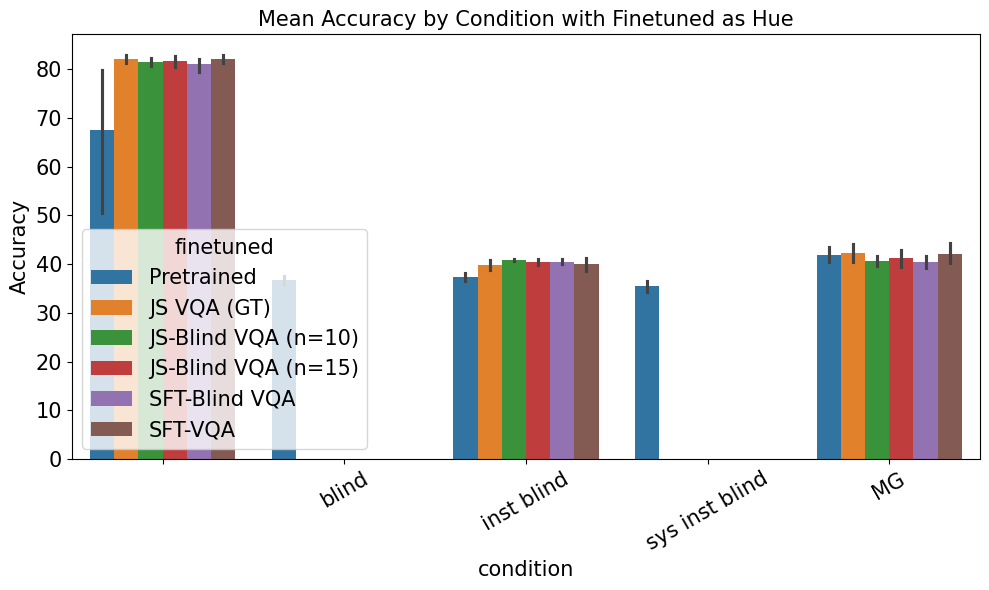

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Barplot of the means for each 'finetuned' hue
plot_df = vp.melt(
    id_vars=['model', 'finetuned', 'trained_dataset'],
    value_vars=[col for col in vp.columns if col not in ['model', 'finetuned', 'trained_dataset']],
    var_name='condition',
    value_name='accuracy'
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x='condition',
    y='accuracy',
    hue='finetuned'
)
plt.title("Mean Accuracy by Condition with Finetuned as Hue")
plt.ylabel('Accuracy')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [6]:
vt['dataset'] = 'VQA'
vt = vt.fillna('Pretrained') 
vt = vt.rename(columns={'correct': 'acc', 'answer_type': 'category'}) 
vt = vt[vt['condition'] == ''].groupby(
    ['dataset', 'strategy', 'blind', 'trained_dataset', 'model', 'finetuned', 'category',]
    )[['acc', 'answer_similarity']].mean().reset_index()
    
vt = vt.melt(id_vars=[col for col in vt.columns if col not in ['acc', 'answer_similarity']], 
        value_vars=['acc', 'answer_similarity'], var_name='score_type', value_name='score')     
vt.finetuned.unique() 


/tmp/ipykernel_1294591/478814880.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vt['dataset'] = 'VQA'


array(['JS-Blind VQA (n=10)', 'JS-Blind VQA (n=15)', 'JS VQA (GT)',
       'Pretrained', 'SFT-Blind VQA', 'SFT-VQA'], dtype=object)

In [ ]:

mt = mm.test_model 
mt['dataset'] = 'MMStar'
mt['score_type'] = 'acc'
mt = mt.rename(columns={'correct': 'score'}) 
mt = mt[mt['condition'] == ''].groupby(['dataset', 'strategy', 'blind', 'trained_dataset', 'model', 'finetuned', 'category', 'score_type'])['score'].mean().reset_index()

dd = pd.concat([vt, mt])
dd = dd.rename(columns={'correct': 'score'})
dd = dd[dd['score_type'] == 'acc']
dd['blind'] = dd['blind'].fillna('Pretrained')

acc = (
    dd[(dd['trained_dataset'] != 'MMStar') & (dd['score_type'] == 'acc') & (dd['strategy'] != 'SFT')]
    # .drop_duplicates(['model', 'blind', 'trained_dataset' , 'strategy', 'dataset', 'category'])
    .pivot_table(
        index=['model', 'blind',  ], #'trained_dataset' , 'strategy' 
        columns=['dataset', 'category'],
        values='score' 
    ) 
).dropna(axis=0) # .to_csv('./tables/finetuned-acc-category.csv', float_format="%.1f", encoding='utf-8') # .reset_index(level=0, drop=True) #
blind_order = ['Pretrained', 'GT', 'Blind', ]

acc = acc.reindex(
    blind_order, 
    level='blind'
) 

In [ ]:
acc.to_latex(f'./tables/acc_by-category.tex', float_format="%.1f")

In [ ]:
pivot = (
    dd[
        (dd['trained_dataset'] == 'VQA') & (dd['dataset'] == 'VQA')
    ]
    .pivot_table(
        index=['model', 'strategy'],
        columns=['blind', 'dataset', 'score_type'],
        values='score'
    )
)

sft_js_comparison = pivot['GT'] - pivot['Blind']
sft_js_comparison.to_latex(f'./tables/sft_js_comparison.tex', float_format="%.1f")  

In [ ]:
delta = (
    (dd[(dd['trained_dataset'] == 'VQA') & (dd['strategy'] == 'JS') ] # & (dd['score_type'] == 'acc') 
    .pivot_table(
        index=['model', 'blind'], # , 'strategy' 
        columns=['dataset', 'category' ,'score_type' ], #  
        values='score'
    ) ) 
) 
delta 

In [ ]:
mt = mm.finetuning_effect(mm.test_model) 
vt = vv.finetuning_effect(vv.test_model) 
vt = vt.rename(columns={'answer_type' : 'category'})
mt['score_type'] = 'accuracy' 
dd = pd.concat([vt, mt])  # .to_csv('./tables/finetuned-delta-sim-category.csv', float_format="%.1f", encoding='utf-8') # .reset_index(level=0, drop=True) # 

In [ ]:
acc, delta = acc.align(delta)

acc_str = acc.map(
    lambda x: f"{x:.1f}" if pd.notna(x) else ""
)

delta_str = delta.map(
    lambda x: f"{x:+.1f}" if pd.notna(x) else ""
)

combined = (
    acc_str
    + " {\\scriptsize("
    + delta_str
    + ")}"
)

combined = combined.where(acc.notna() & delta.notna(), "")
combined.to_latex(
    "./tables/finetuned-acc-delta-category.tex",
    escape=False
) 

/tmp/ipykernel_616186/1337095857.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  acc_str = acc.applymap(
/tmp/ipykernel_616186/1337095857.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  delta_str = delta.applymap(


In [ ]:

pd.merge(mmstar, vqa.reset_index(), on=['model', 'finetuned'], suffixes=(' MMStar', ' VQA')) 

In [ ]:

vqadf, vqapt = vv.finetuning_effect(test_model) 
vqadf = vqadf.melt(id_vars=['model', 'finetuned', 'model_size', 'question_id', 'answer_type', 'question_type'], value_vars=['delta_acc', 'delta_sim'], var_name='score_type', value_name='delta') 
# vqadf.groupby(['model', 'finetuned', 'model_size', 'score_type']).count()
vqa=vqadf.pivot_table(index=['model', 'finetuned', 'model_size'], columns=['answer_type'], values=['delta']).droplevel(0, axis=1) 

model_mg = vv.model_mg
test_model_mg = vv.test_model_mg # get_mg(test_model, filename='5k-test')   

In [ ]:

dfdf = mm.finetuning_effect(mm.test_model)
dfdf.groupby(['model', 'finetuned'])[['correct', 'correct_baseline']].count()

mmstar = dfdf.pivot_table(
    index=['model', 'finetuned'], # ['model', 'family', 'model_size', 'finetuned'], 
    values='delta', 
    aggfunc='mean'
).reset_index() 

dd = dd[dd['finetuned']!='JS-Blind VQA (n=10)']
            index=['trained_dataset', 'model', 'strategy'],  #  , 'finetuned' 

pd.merge(mmstar, vqa.reset_index(), on=['model', 'finetuned'], suffixes=(' MMStar', ' VQA')) 


In [ ]:

dd[dd['trained_dataset']=='MMStar'].pivot_table(
            columns=['bias'] , 
            values=['delta']).assign(Average=lambda x: x.mean(axis=1)).reset_index(level=0, drop=True).to_latex('./tables/spubench-mmstar_finetuned-delta.tex', float_format="%.2f")
             
dd[dd['trained_dataset']=='VQA'].pivot_table(
            index=['trained_dataset', 'model', 'strategy', 'blind'],  #  , 'finetuned' 
            columns=['bias'] , 
            values=['delta']).assign(Average=lambda x: x.mean(axis=1)).reset_index(level=0, drop=True).to_latex('./tables/spubench-VQA_finetuned-delta.tex', float_format="%.2f")
             

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='paper')

pt = dfdf.pivot_table(
    index=['model', 'finetuned'],
    columns='category',
    values='delta',
    aggfunc='mean'
)
pt.to_csv('./tables/appendix-mmstar-category-heatmap.csv')

plt.figure(figsize=(7, 7))
ax = sns.heatmap(pt,
    annot=True,
    fmt='.1f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Δ Score'}
)
plt.tight_layout()
plt.show()


ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 700x700 with 0 Axes>